# Retained states and every PCAT proposal

This notebook runs a seeded simulated two-line Voigt spectrum. The first animation contains retained chain-state frames at the configured plotting cadence. The second contains every proposed candidate before the Metropolis-Hastings decision, including candidates that are rejected. This short run demonstrates output semantics rather than posterior convergence.

In [1]:
from IPython.display import Image, display
import numpy as np

from pcat.main import readfile
from proposal_state_animation import EXAMPLE_PATH, RUN_NAME, run_example

products = run_example(number_sweeps=24)
worker = readfile(str(EXAMPLE_PATH / "data" / "outp" / RUN_NAME / "gdatmodi0000post"))
accepted = np.asarray(worker.listpostboolpropaccp).reshape(-1).astype(bool)
{
    "sweeps": accepted.size,
    "accepted": int(accepted.sum()),
    "rejected": int((~accepted).sum()),
    "proposal_types": sorted(set(np.asarray(worker.listpostindxproptype).reshape(-1).astype(int))),
}

{'sweeps': 24,
 'accepted': 4,
 'rejected': 20,
 'proposal_types': [np.int64(0),
  np.int64(1),
  np.int64(2),
  np.int64(3),
  np.int64(4)]}

## Retained chain states

These frames show the state retained by the Markov chain at the sparse plotting cadence. A rejected proposal therefore leaves the displayed chain state unchanged.

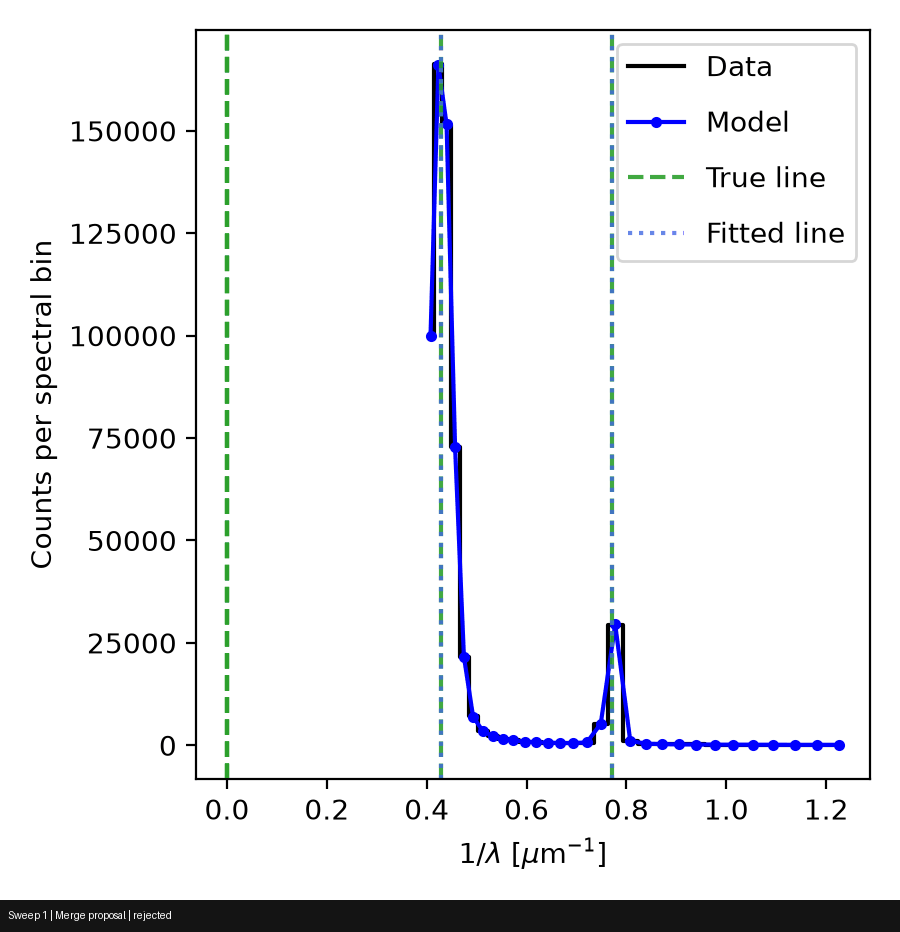

In [2]:
display(Image(filename=str(products["posterior_animation"])))

## Every proposed candidate

Set `boolmakeanimprop=True` to write one frame per sweep. Each frame compares the current and candidate predictions and unit-prior coordinates, then reports the move type, prior-support result, acceptance probability, accept/reject result, log posterior change, proposal-density ratio, and Jacobian.

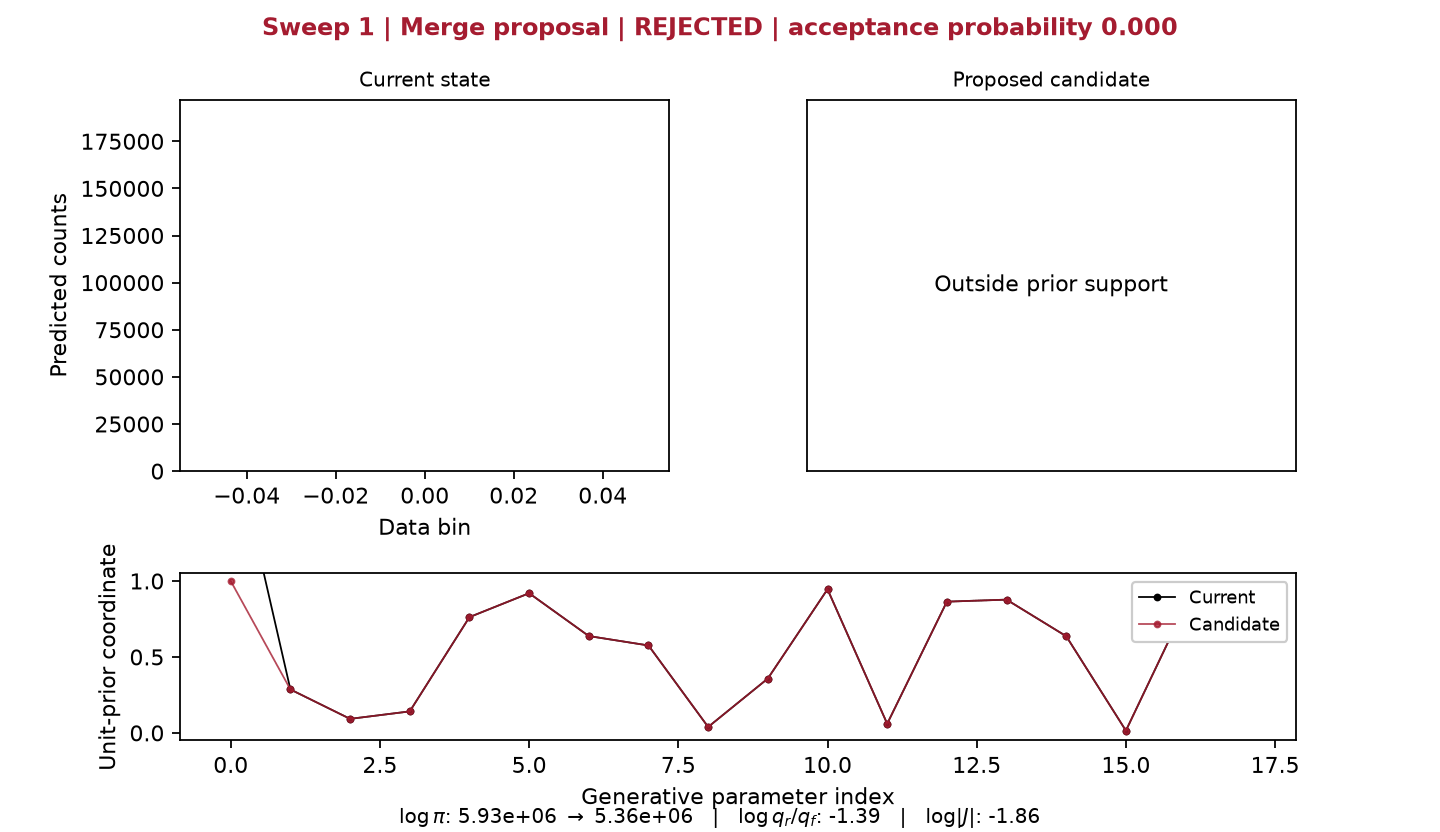

In [3]:
display(Image(filename=str(products["proposal_animation"])))